# CORGI forward model tutorial
In this Jupyter notebook, I will walk you through the basic forward modeling functionalities of CORGI:
- Generate Earth models and compare with the preliminary reference Earth model (PREM)
- Generate a Sub-Neptune model and compare it with K2-18 b models presented in Madhusudhan et al. (2020)
- Generate Neptune and Uranus models and compared them to models presented in Nettelmann et al. (2013)

First, import all relevant packages.

In [1]:
# import CORGI modules
import simpleMR as smr # where most calculation happens
import plotMR as pltmr # it's called plotMR, but used as a general I/O script to read/write text files
import EOS as eos # equation of state (EOS) calculations
import temperature_profile as tpr # temperature-pressure (T-P) profile calculations

# import other modules
import datetime
import numpy as np

# import matplotlib and set plotting styles
from matplotlib import pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['mathtext.fontset'] = 'stix'
from matplotlib.ticker import MultipleLocator, AutoLocator, AutoMinorLocator
from matplotlib import colors
import matplotlib.cm as cm

Loading Seager et al. 2007 H2O EOS ...
Completed

Loading Zeng et al. 2021 H2O EOS ...
Completed

Loading Seager et al. 2007 Fe EOS ...
Completed

Loading Zeng et al. 2016 core EOS ...
Completed

Loading Zeng et al. 2021 core EOS ...
Completed

Loading Smith et al. 2018 solid iron EOS ...
Completed

Loading Grant et al. 2021 liquid iron EOS ...
Completed

Loading Seager et al. 2007 MgSiO3 (en) EOS ...
Completed

Loading Seager et al. 2007 MgSiO3 (pv) EOS ...
Completed

Loading Hubbard & Marley 1989 analytical rock EOS ...
Completed

Loading Seager et al. 2007 MgSiO3 (iron-rich pv) EOS ...
Completed

Loading Zeng et al. 2016 mantle EOS ...
Completed

Loading Zeng et al. 2021 mantle EOS ...
Completed

Loading Oganov & Ono 2004 MgSiO3 (ppv) EOS ...
Completed

Loading Seager et al. (2007) carbon (graphite) EOS ...
Completed

Loading Swift et al. (2022) carbon (diamond) EOS ...
Completed

Loading SiC zinc-blende structure EOS ...
Completed

Loading SiC rock-salt structure EOS ...
Completed


In [2]:
# define some constants in SI; CORGI uses SI units everywhere
G = 6.67408e-11  # gravitational constant
Re = 6371000.0  # Earth radius
Me = 5.97e24  # Earth mass
kb = 1.380649e-23 # Boltzmann constant, J/K
massH = 1.66053906660e-27 # mass of H atom in kg

# (1) Generate Earth models and compare with PREM
Key input parameters:
- $P_c$ = 380 GPa (realistic Earth central pressure), or 434.1 GPa (gives M and R closest to 1 Me and 1 Re)
- Core mass fraction (CMF) is 32.5%

Key parameters we need to match:
- Core radius: 3486 km, or about 55% of Earth's total radius
- $1\,M_\oplus$ and $1\,R_\oplus$ mass and radius
- Good match with PREM $\rho(r)$ and the geotherm $T(P)$
 
Run two models - isothermal and adiabatic - using the `smr.run_single_planet_4layers()` function.

## (1-1) Earth with adiabatic $T-P$ profile

The core of CORGI's forward model is the `smr.run_single_planet_4layers` function, which allows you to define the layer mass fractions, central pressure, central temperature, etc., and simulate the planet's pressure, density, mass, radius, and temperature from inside out in many concentric layers like onion shells.

In [3]:
# track the time performance of the code
begin_time = datetime.datetime.now()

# calling the function; there are 17 output parameters, but we usually don't need all of them
_, m_earth_adib20, r_earth_adib20, _, _, _, mlist_earth_adib20, rlist_earth_adib20, \
plist_earth_adib20, tlist_earth_adib20, rholist_earth_adib20, _, mb_adib20, \
rb_adib20, pb_adib20, tb_adib20, _ = \
    smr.run_single_planet_4layers(
        pmass=Me, # target planet mass, simply 1 Me here
        layer_mass_fractions=[325000, 675000, 0, 0], # 32.5% core, 67.5% mantle, no outer layers; should be a list of integers summing to 1,000,000
        pc=434.1e9, # Pc = 434.1 GPa gives good fit
        ps=1.0e3, # use 1000 Pa or 0.01 bar as "surface" pressure
        tc=5500.0, # core temperature
        rc=10.0, # radius of the central sphere to start calculation with
        delr=100.0, # thickness of each sphere
        tmode_core='adiabatic_Boujibar_2020', # which temperature profile to use
        eos_core='iron_with_phase_change', # EOS for the iron core
        eos_mantle='tab_Zeng16 Zeng2016_mantle' # EOS for the silicate mantle
    ) 

# print results
print()
print("Adiabatic model (2-layer) for Earth done.")
print("M, R calculated are: %f M_Earth, %f R_Earth" % (m_earth_adib20/Me, r_earth_adib20/Re))
print("Surface pressure is: %f bar" % (plist_earth_adib20[-1]/1.0e5))
print("Execution time: ", datetime.datetime.now() - begin_time)

Iteration stopped at step 32837, P = 1523542.098369 bar, M = 0.324888 M_Earth, R = 0.515415 R_Earth
Iteration stopped at step 30035, P = 14.012950 bar, M = 0.999511 M_Earth, R = 0.986833 R_Earth

Adiabatic model (2-layer) for Earth done.
M, R calculated are: 0.999880 M_Earth, 0.986833 R_Earth
Surface pressure is: 14.012950 bar
Execution time:  0:00:01.505545


We can see that this set of parameter give us M and R very close to $1\,M_\oplus$ and $1\,R_\oplus$, with a very small error in mass and a <2% error in radius. This is great. Let's write the results to a text file.

One thing I should point out is that `tmode_core` is a misleading name in some way: the mantle is also considered "core" and uses the same temperature profile. This is because naming conventions are different for different types of planets. For terrestrial planets, only the iron part is "core." For sub-Neptunes and other massive planets, however, the entire interior iron-silicate part are called "core" as compared to an icy "mantle." I follow the second convention here. 

In [4]:
# write the results to a text file
pltmr.write_planet_to_txt(mlist_earth_adib20, rlist_earth_adib20, plist_earth_adib20, 
                          rholist_earth_adib20, mb_adib20, rb_adib20, pb_adib20,
                          tlist=tlist_earth_adib20, tboundary=tb_adib20, outdir='Results/', 
                          pname='Earth_adiabatic_iron_silicate_2layer')

## (1-2) Earth with isothermal $T-P$ profile

In [5]:
# track the time performance of the code
begin_time = datetime.datetime.now()

# calling the function
_, m_earth_iso, r_earth_iso, _, _, _, mlist_earth_iso, rlist_earth_iso, plist_earth_iso, \
tlist_earth_iso, rholist_earth_iso, _, mb_iso, rb_iso, pb_iso, tb_iso, _ = \
    smr.run_single_planet_4layers(
        pmass=Me,
        layer_mass_fractions=[325000, 675000, 0, 0], # 32.5% CMF
        pc=438.09e9, # Pc = 438.09 GPa gives good fit for the isothermal model
        ps=1.0e3,
        tc=300.0, 
        rc=10.0, 
        delr=100.0,
        tmode_core='isothermal'
)

# print the results
print()
print("Isothermal model (2-layer) for Earth done.")
print("M, R calculated are: %f M_Earth, %f R_Earth" % (m_earth_iso/Me, r_earth_iso/Re))
print("Surface pressure is: %f bar" % (plist_earth_iso[-1]/1.0e5))
print("Execution time: ", datetime.datetime.now() - begin_time)

Iteration stopped at step 32795, P = 1546710.003733 bar, M = 0.324905 M_Earth, R = 0.514756 R_Earth
Iteration stopped at step 29057, P = 45.552959 bar, M = 0.999636 M_Earth, R = 0.970838 R_Earth

Isothermal model (2-layer) for Earth done.
M, R calculated are: 1.000005 M_Earth, 0.970838 R_Earth
Surface pressure is: 45.552959 bar
Execution time:  0:00:01.078920


In [6]:
# write the results to a text file
pltmr.write_planet_to_txt(mlist_earth_iso, rlist_earth_iso, plist_earth_iso, rholist_earth_iso,
                          mb_iso, rb_iso, pb_iso, tlist=tlist_earth_iso, tboundary=tb_iso, outdir='Results/', 
                          pname='Earth_isothermal_iron_silicate_2layer')

## (1-3) Overplot results with PREM
Now let's overplot the above profiles with the PREM Earth model and the geotherm from Hirose et al. (2013), to check that if `CORGI` is reproducing the interior of the Earth with good enough precision.

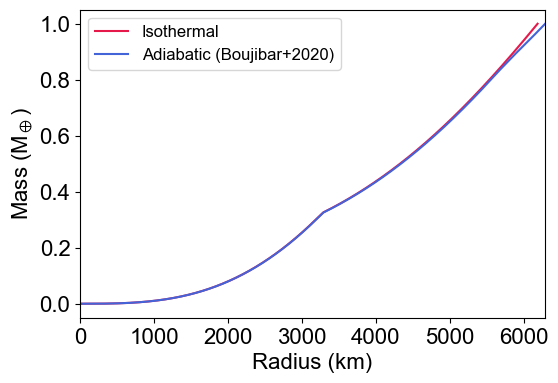

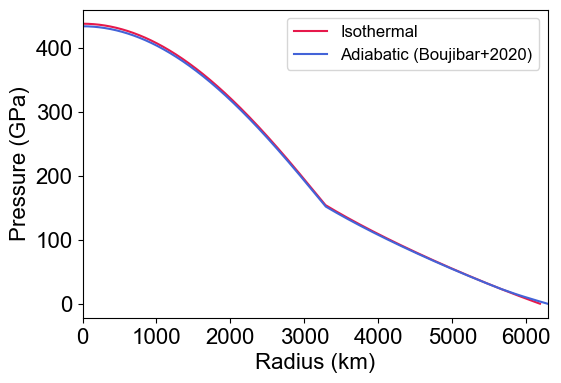

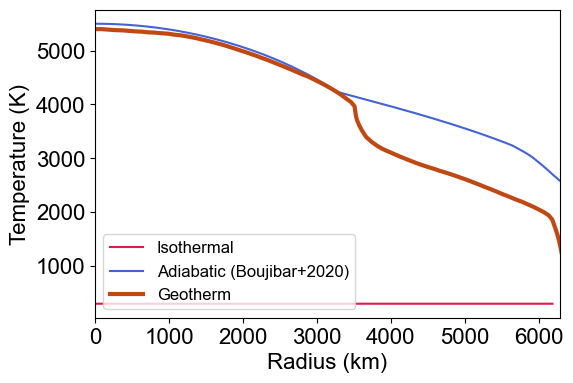

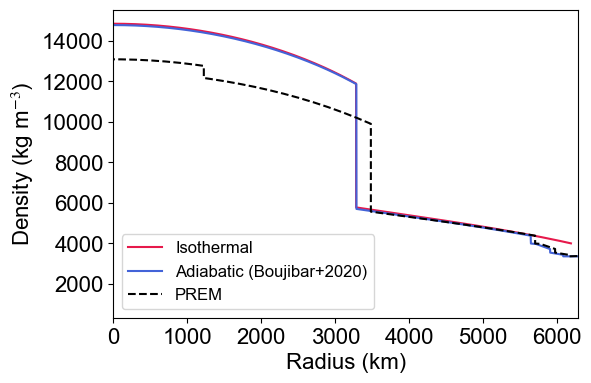

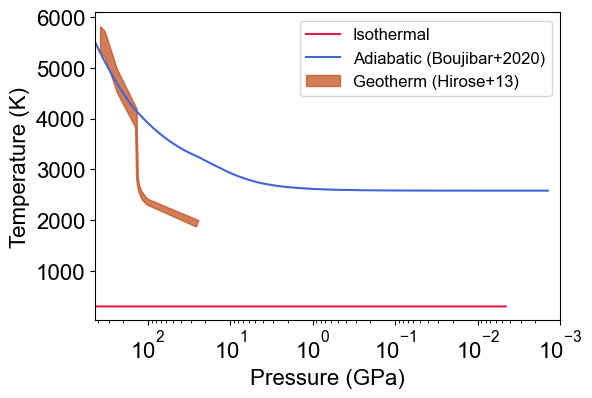

In [7]:
# profiles from simulations above
mll = [mlist_earth_iso, mlist_earth_adib20]
rll = [rlist_earth_iso, rlist_earth_adib20]
pll = [plist_earth_iso, plist_earth_adib20]
tll = [tlist_earth_iso, tlist_earth_adib20]
rholl = [rholist_earth_iso, rholist_earth_adib20]
pnames = ['Isothermal', 'Adiabatic (Boujibar+2020)']

for i in range(len(mll)):
    mll[i] = list(map(lambda x: x / Me, mll[i]))  # convert kg to Me
    rll[i] = list(map(lambda x: x / 1000.0, rll[i]))  # convert m to km
    pll[i] = list(map(lambda x: x / 1.0e9, pll[i]))  # convert P to GPa
    
rmax = max(list(map(lambda l: max(l), rll)))
pmax = max(list(map(lambda l: max(l), pll)))

# not quite useful for only 2 models, but handy when there are a lot of models to compare
colors = ['#e6194b', '#4363d8', '#3cb44b', '#ffe119', '#f58231', '#911eb4', '#46f0f0', 
          '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', 
          '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']

# range of geotherm from Hirose et al. 2013 (in P-T space)
h13_geotherm_pts = [[24.161929980263565, 1992.6266239742235],
 [25.779480291800553, 1865.6791761354825],
 [103.29879303338068, 2303.94492018858],
 [116.95357105758562, 2399.492647581419],
 [128.19286681452297, 2550.5411576892866],
 [133.4071703621629, 2669.7070149125884],
 [136.61037922041947, 2812.636792891234],
 [137.79866637751468, 3026.9494524639576],
 [138.58320379202195, 3265.062480523243],
 [139.76702610204273, 3534.9305944078237],
 [140.94893490617443, 3828.608188711772],
 [232.91585494531927, 4497.360273066402],
 [328.49674977356847, 5197.940338708766],
 [375.1001857011906, 5318.044725010979],
 [375.0600020775207, 5818.043813817699],
 [328.8571267160047, 5713.821526394535],
 [234.48492977433386, 4973.586329184974],
 [134.89268876735593, 4185.613716010212],
 [134.9118238262464, 3947.5189118165363],
 [134.13111342351715, 3661.7869229185153],
 [132.54928188857565, 3344.2907362623937],
 [130.58155999934394, 2828.373100845404],
 [126.1728424309908, 2685.4159870683443],
 [118.54752146315771, 2566.195458248212],
 [100.47700968233984, 2414.992045282661]]
h13_ps = list(map(lambda x: x[0], h13_geotherm_pts))
h13_ts = list(map(lambda x: x[1], h13_geotherm_pts))

# read PREM rho(r) model
prem = np.genfromtxt('Data/PREM_1s.txt', comments='#', delimiter=',')
prem = np.transpose(prem)
prem_r = prem[0]
prem_rho = prem[2]
prem_rho = list(map(lambda x: x * 1000.0, prem_rho)) # convert g cm-3 into kg m-3

# read T(r) geotherm model
earle_geotherm = np.genfromtxt('Data/geotherm_earle.txt', comments='#')
earle_geotherm = np.transpose(earle_geotherm)
earle_geotherm_r = Re/1000.0 - earle_geotherm[1] # depth to radius
earle_geotherm_t = earle_geotherm[0] + 273.15 # C to K

# plot M(r)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(len(mll)):
    plt.plot(rll[i], mll[i], color=colors[i], linestyle='-', label=pnames[i])
plt.xlabel('Radius (km)', fontsize=16)
plt.ylabel(r'Mass (M$_\oplus$)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim([0, rmax])
plt.legend(fontsize=12)
plt.show()
plt.close()

# plot P(r)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(len(mll)):
    plt.plot(rll[i], pll[i], color=colors[i], linestyle='-', label=pnames[i])
plt.xlabel('Radius (km)', fontsize=16)
plt.ylabel('Pressure (GPa)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim([0, rmax])
plt.legend(fontsize=12)
plt.show()
plt.close()

# plot T(r)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(len(mll)):
    plt.plot(rll[i], tll[i], color=colors[i], linestyle='-', label=pnames[i])
plt.plot(earle_geotherm_r, earle_geotherm_t, color='#c04813', linewidth=3, label='Geotherm')
# print(earle_geotherm_r, earle_geotherm_t)
plt.xlabel('Radius (km)', fontsize=16)
plt.ylabel('Temperature (K)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim([0, rmax])
plt.legend(fontsize=12, loc="lower left")
plt.show()
plt.close()

# plot rho(r)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(len(mll)):
    plt.plot(rll[i], rholl[i], color=colors[i], linestyle='-', label=pnames[i])
plt.xlabel('Radius (km)', fontsize=16)
plt.ylabel(r'Density (kg m$^{-3}$)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim([0, rmax])
plt.plot(prem_r, prem_rho, 'k--', label='PREM')
plt.legend(fontsize=12)
plt.show()
plt.close()

# plot T(P)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(len(mll)):
    plt.plot(pll[i], tll[i], color=colors[i], linestyle='-', label=pnames[i])
plt.fill(h13_ps, h13_ts, color='#c04813', alpha=0.7, label='Geotherm (Hirose+13)')
plt.xlabel('Pressure (GPa)', fontsize=16)
plt.ylabel('Temperature (K)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xscale('log')
plt.xlim([pmax, 1.0e-3])
plt.legend(fontsize=12)
plt.show()
plt.close()

In [8]:
# check the core radius fraction (CRF)
print(rb_adib20) # radius at the core-mantle boundary and at surface (i.e., total radius)
print(rb_adib20[0]/rb_adib20[1]) # CRF, my model
print(3480.0/6371.0) # CRF, PREM

[3283710.0, 6287110.0]
0.5222924364294564
0.5462250824046461


**Comments on $\rho(r)$ profile**

The $\rho(r)$ profile is generally in good agreement with PREM. One key difference is that my model predict a denser core than PREM. Also, my model does not account for solid-liquid phase transition at the inner-outer core boundary (the EOS is isothermal). The core is denser in my model likely because my EOS does not include light elements, while the Earth has a least a few percent light elements in the core.

Another difference is the low pressure phase transition of silicates near the surface (enstatite vs pv/ppv). The isothermal model uses the default mantle EOS from Zeng et al. (2021), as you may notice that I did not define `eos_mantle` in the call for the isothermal model. The Zeng et al. (2021) EOS is slightly denser in the low pressure regime, because it does not incorporate phase changes of MgSiO$_3$ at low pressures. The Zeng et al. (2016) mantle EOS, which is used in the adiabatic model, includes these phase changes and therefore shows better agreement with PREM.

Finally, the core radius fraction (CRF) predicted by my model is 52.2%, while in PREM the CRF is 54.6%. Also note that the radius I predict is 0.970838-0.986833 $R_\oplus$, not exactly $1\,R_\oplus$. All these differences are expected because this code is a general interior modeling code not fine tuned based on Earth's observables.

**Comments on $T(r)$ and $T(P)$ profiles**

The Boujibaret al. (2020) adiabatic P-T profile matches the geotherm in the core very nicely. However, it is a fully adiabatic profile not taking core mantle boundary effects into consideration, so the mantle is too hot. A possible workaround is to manually define some thermal boundary layer, i.e., a jump in $T$, at the core-mantle boundary.

# (2) Generate sub-Neptune model using K2-18 b parameters
Key input parameters:
- $8.63\,M_\oplus$, $2.61\,R_\oplus$

Compare against:
- Three different compositional models for K2-18 b from Madhusudhan et al. (2020)

Key parameters we need to match:
- match M and R with reasonable central pressure
- pressure vs density profiles (Fig. 4)
- P-T profiles and location of H/He-H2O boundary (Fig. 4)

## (2-1) Model #1 - 94.7% iron core, 0.3% H2O, and 5% H/He
This very iron-rich model is an extreme case. In reality, planet formation probably won't lead to such an extremely iron-rich composition. Nonetheless, it is compatible with the measured mass and radius of K2-18 b.

In [9]:
# track the time performance of the code
begin_time = datetime.datetime.now()

# call the function
pmass3l, pmass_calc3l, rs3l, ps3l, ts3l, rhos3l, \
mlist3l, rlist3l, plist3l, tlist3l, rholist3l, taulist3l, \
mboundary3l, rboundary3l, pboundary3l, tboundary3l, lnames_3l = \
    smr.run_single_planet_4layers(
        pmass=8.63*smr.Me, # K2-18 b mass
        layer_mass_fractions=[947000, 0, 3000, 50000], 
        pc=5816.6e9, # 5816.6e9 Pa matches the M-R with the given layer mass fractions
        ps=301.0, # surface pressure set to some arbitrary small number (0.03 bar in this case)
        tc=5500.0,
        rc=10.0, 
        delr=100.0,
        bc_ignore='', # boundary condition to ignore; empty '' by default
        pradius=2.61*smr.Re, # K2-18 b radius
        mmw=3.8504579876320796e-27, # mean molecular weight of H/He atmosphere
        teff=50.0, # internal temperature of the planet
        teq=254.9, # Benneke et al. (2019) Teq
        guillot_f=0.5, # parameter for calculating the Guillot (2010) analytical P-T model
        guillot_gamma=1.0 # parameter for calculating the Guillot (2010) analytical P-T model
)

# print results
print()
print("3-layer K2-18 b model (1) simulation completed.")
print("Execution time: ", datetime.datetime.now() - begin_time)
print()
print("The measured mass and radius of K2-18 b are")
print("8.63 Me\t2.61 Re")
print("The calculated mass and radius are")
print(pmass_calc3l/smr.Me, "Me", rlist3l[-1]/smr.Re, "Re")
print()
print("Surface pressure is", plist3l[-1]/1.0e5, "bar")
print("Surface temperature is", tlist3l[-1], "K")
print()
ml0 = mboundary3l[0]
ml1 = (mboundary3l[1]-mboundary3l[0])
ml2 = (mboundary3l[2]-mboundary3l[1])
print("Masses at layer boundaries are", ml0/smr.Me, "Me,", ml1/smr.Me, "Me,", ml2/smr.Me, "Me")
print("Which corresponds to layer mass fraction of %f:%f:%f" % (ml0/pmass_calc3l, ml1/pmass_calc3l, ml2/pmass_calc3l))

Iteration stopped at step 83466, P = 604444.635523 bar, M = 8.172722 M_Earth, R = 1.310094 R_Earth
Iteration stopped at step 816, P = 523612.978474 bar, M = 8.198515 M_Earth, R = 1.322902 R_Earth
Calculating H/He envelope (convective layer) ...
Iteration stopped at step 94941, P = 0.003008 bar, M = 8.616164 M_Earth, R = 2.813108 R_Earth
H/He envelope (convective layer) simulation completed.
Execution time:  0:00:01.762391
The RCB is at P = 1.413409 bar
Calculating H/He envelope (radiative layer) ...
Iteration stopped at step 5094, P = 0.003009 bar, M = 8.616164 M_Earth, R = 2.813626 R_Earth
H/He envelope (radiative layer) simulation completed.
Execution time:  0:00:00.436047
Optical depth = 1 at 0.290503 bar

3-layer K2-18 b model (1) simulation completed.
Execution time:  0:00:04.045508

The measured mass and radius of K2-18 b are
8.63 Me	2.61 Re
The calculated mass and radius are
8.616162401531103 Me 2.7538235755768325 Re

Surface pressure is 0.29050347069438753 bar
Surface temperatu

Now both M and R are in good match with observation. R calculated by `CORGI` is 0.16 Re greater than observation, possibly due to e.g. different EOS used by Madhusudhan et al. (2020).

In [10]:
# write results to text file
pltmr.write_planet_to_txt(mlist3l, rlist3l, plist3l, rholist3l,
                          mboundary3l, rboundary3l, pboundary3l,
                          tlist=tlist3l, tboundary=tboundary3l, 
                          layer_name_list=lnames_3l,
                          outdir='Results/', pname='K2-18b_model1_iron_rich')

## (2-2) Model #2 - 45% Earth-like core (33% Fe + 67% silicates), 54.97% H2O, and 0.03% H/He

In [11]:
# track the time performance of the code
begin_time = datetime.datetime.now()

# call the function
pmass4l, pmass_calc4l, \
rs4l, ps4l, ts4l, rhos4l, mlist4l, rlist4l, plist4l, tlist4l, rholist4l, taulist4l, \
mboundary4l, rboundary4l, pboundary4l, tboundary4l, lnames_4l = \
    smr.run_single_planet_4layers(
        pmass=8.63*smr.Me, 
        layer_mass_fractions=[148500, 301500, 549700, 300], 
        pc=2409.0e9, # 2409.0e9 Pa matches the M-R with the given layer mass fractions
        ps=301.0, 
        tc=8000.0, # Tc is higher for this case following Madhusudhan+2020
        rc=10.0, 
        delr=100.0,
        bc_ignore='',
        pradius=2.61*smr.Re, 
        mmw=3.8504579876320796e-27, 
        teff=50.0, 
        teq=254.9, # Benneke et al. (2019) Teq
        guillot_f=0.5, 
        guillot_gamma=1.0,
        maxsteps=2000000 # max integration steps, to catch edge cases that keeps running
)

# print results
print()
print("4-layer K2-18 b model (2) simulation completed.")
print("Execution time: ", datetime.datetime.now() - begin_time)
print()

print("The measured mass and radius of K2-18 b are")
print("8.63 Me\t2.61 Re")
print("The calculated mass and radius are")
print(pmass_calc4l/smr.Me, "Me", rlist4l[-1]/smr.Re, "Re")
print()
print("Surface pressure is", plist4l[-1]/1.0e5, "bar")
print("Surface temperature is", tlist4l[-1], "K")
print()
ml0 = mboundary4l[0]
ml1 = (mboundary4l[1]-mboundary4l[0])
ml2 = (mboundary4l[2]-mboundary4l[1])
ml3 = (mboundary4l[3]-mboundary4l[2])
print("Masses at layer boundaries are", ml0/smr.Me, "Me,", ml1/smr.Me, "Me,", 
      ml2/smr.Me, "Me", ml3/smr.Me, "Me")
print("Which corresponds to layer mass fraction of %f:%f:%f:%f" % (ml0/pmass_calc4l, ml1/pmass_calc4l, 
                                                                   ml2/pmass_calc4l, ml3/pmass_calc4l))

Iteration stopped at step 44460, P = 10983905.876140 bar, M = 1.281611 M_Earth, R = 0.697851 R_Earth
Iteration stopped at step 36860, P = 3523406.063553 bar, M = 3.883513 M_Earth, R = 1.276410 R_Earth
Iteration stopped at step 72219, P = 466.341277 bar, M = 8.627412 M_Earth, R = 2.409969 R_Earth
Calculating H/He envelope (convective layer) ...
Iteration stopped at step 18683, P = 0.003007 bar, M = 8.629158 M_Earth, R = 2.703219 R_Earth
H/He envelope (convective layer) simulation completed.
Execution time:  0:00:00.374299
The RCB is at P = 0.562896 bar
Calculating H/He envelope (radiative layer) ...
Iteration stopped at step 3996, P = 0.003008 bar, M = 8.629158 M_Earth, R = 2.703345 R_Earth
H/He envelope (radiative layer) simulation completed.
Execution time:  0:00:00.357430
Optical depth = 1 at 0.301637 bar

4-layer K2-18 b model (2) simulation completed.
Execution time:  0:00:03.070457

The measured mass and radius of K2-18 b are
8.63 Me	2.61 Re
The calculated mass and radius are
8.62

In [12]:
# write results to text file
pltmr.write_planet_to_txt(mlist4l, rlist4l, plist4l, rholist4l,
                          mboundary4l, rboundary4l, pboundary4l,
                          tlist=tlist4l, tboundary=tboundary4l, layer_name_list=lnames_4l,
                          outdir='Results/', pname='K2-18b_model2_neptune_like')

## (2-3) Model #3 - 10% Earth-like core, 89.994% H2O, and 0.006% H/He

In [13]:
# track the time performance of the code
begin_time = datetime.datetime.now()

# call the function
pmass_water_world, pmass_calc_water_world, \
rs_water_world, ps_water_world, ts_water_world, rhos_water_world, mlist_water_world, \
rlist_water_world, plist_water_world, tlist_water_world, rholist_water_world, taulist_water_world, \
mboundary_water_world, rboundary_water_world, pboundary_water_world, \
tboundary_water_world, lnames_water_world = \
    smr.run_single_planet_4layers(pmass=8.63*smr.Me, layer_mass_fractions=[33000, 67000, 899940, 60], 
                                  pc=1062.89e9, # pc=1062.38 GPa is a good guess
                                  ps=301.0, tc=5500.0, 
                                  rc=10.0, delr=100.0,
                                  bc_ignore='',
                                  pradius=2.61*smr.Re, mmw=3.8504579876320796e-27, 
                                  teff=50.0, teq=254.9, # Benneke et al. (2019) Teq
                                  guillot_f=0.5, guillot_gamma=1.0,
                                  maxsteps=2000000)

# print results
print()
print("4-layer K2-18 b model (3) simulation completed.")
print("Execution time: ", datetime.datetime.now() - begin_time)
print()

print("The measured mass and radius of K2-18 b are")
print("8.63 Me\t2.61 Re")
print("The calculated mass and radius are")
print(pmass_calc_water_world/smr.Me, "Me", rlist_water_world[-1]/smr.Re, "Re")
print()
print("Surface pressure is", plist_water_world[-1]/1.0e5, "bar")
print("Surface temperature is", tlist_water_world[-1], "K")
print()
ml0 = mboundary_water_world[0]
ml1 = (mboundary_water_world[1]-mboundary_water_world[0])
ml2 = (mboundary_water_world[2]-mboundary_water_world[1])
ml3 = (mboundary_water_world[3]-mboundary_water_world[2])
print("Masses at layer boundaries are", ml0/smr.Me, "Me,", ml1/smr.Me, "Me,", 
      ml2/smr.Me, "Me,", ml3/smr.Me, "Me")
print("Which corresponds to layer mass fraction of %f:%f:%f:%f" % (ml0/pmass_calc_water_world, 
                                                                   ml1/pmass_calc_water_world, 
                                                                   ml2/pmass_calc_water_world, 
                                                                   ml3/pmass_calc_water_world))

Iteration stopped at step 28538, P = 6994086.478342 bar, M = 0.284807 M_Earth, R = 0.447938 R_Earth
Iteration stopped at step 21601, P = 4674492.765930 bar, M = 0.863022 M_Earth, R = 0.786989 R_Earth
Iteration stopped at step 114772, P = 110.593749 bar, M = 8.629483 M_Earth, R = 2.588465 R_Earth
Calculating H/He envelope (convective layer) ...
Iteration stopped at step 10054, P = 0.003007 bar, M = 8.630003 M_Earth, R = 2.746274 R_Earth
H/He envelope (convective layer) simulation completed.
Execution time:  0:00:00.165471
The RCB is at P = 3.548997 bar
Calculating H/He envelope (radiative layer) ...
Iteration stopped at step 5520, P = 0.003007 bar, M = 8.630003 M_Earth, R = 2.746305 R_Earth
H/He envelope (radiative layer) simulation completed.
Execution time:  0:00:00.443628
Optical depth = 1 at 0.296194 bar
Calculated mass greater than input mass, upper atmosphere truncated.

4-layer K2-18 b model (3) simulation completed.
Execution time:  0:00:02.624143

The measured mass and radius o

In [14]:
# write results to text file
pltmr.write_planet_to_txt(mlist_water_world, rlist_water_world, plist_water_world, rholist_water_world,
                          mboundary_water_world, rboundary_water_world, pboundary_water_world,
                          tlist=tlist_water_world, tboundary=tboundary_water_world, 
                          layer_name_list = lnames_water_world,
                          outdir='Results/', pname='K2-18b_model3_water_world')

## (2-4) Compare all three models

In [15]:
print(np.array(rboundary3l)/smr.Re)
print(np.array(rboundary4l)/smr.Re)
print(np.array(rboundary_water_world)/smr.Re)

[1.31009418 1.32290221 2.75382358]
[0.6978512  1.2764103  2.40996861 2.64795323]
[0.44793753 0.78698948 2.58846492 2.680868  ]


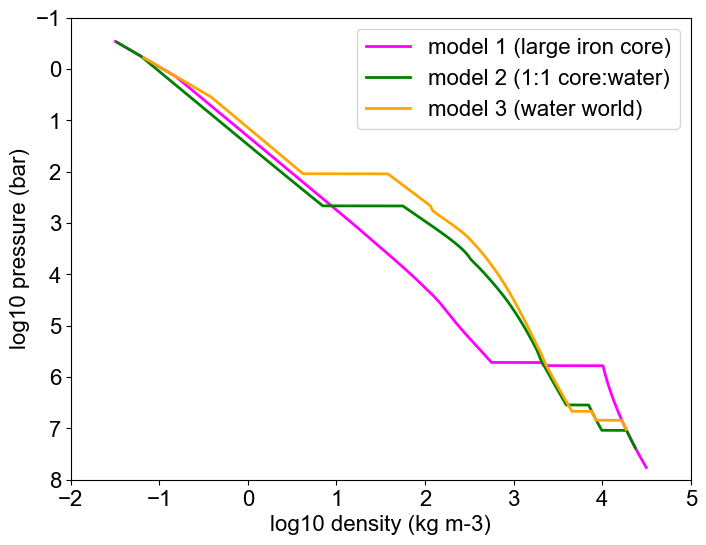

In [16]:
# plot pressure vs density, similar to Fig. 4 (left) in Madhusudhan+2020, for all three cases
fig, ax = plt.subplots(figsize=(8,6))
plt.plot(np.log10(rholist3l), np.log10(plist3l)-5, color='magenta', linewidth=2,
         label='model 1 (large iron core)')
plt.plot(np.log10(rholist4l), np.log10(plist4l)-5, color='g', linewidth=2,
         label='model 2 (1:1 core:water)')
plt.plot(np.log10(rholist_water_world), np.log10(plist_water_world)-5, color='orange',
         linewidth=2, label='model 3 (water world)')
plt.xlabel('log10 density (kg m-3)', fontsize=16)
plt.ylabel('log10 pressure (bar)', fontsize=16)
plt.xlim([-2, 5])
plt.ylim([8, -1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.show()
plt.close()

This agrees nicely with Figure 4 of Madhusudhan et al. (2020), validating my model. The only significant difference is that the green model (1:1 ice:rock planet) has higher density in my model compared to Madhusudhan+2020 in the water layer. The H/He-H2O boundary is also at lower pressure in my model. Given the sensitivity of atmosphere at low pressures, especially the sensitivity on temperature and EOS, this makes sense.

However, note that to get the H/He atmosphere correct (i.e., making sure the upper atmosphere is not cut off at too high pressure, which will make the planetary radius too low), central pressure needs to be tuned pretty precisely. This is an intrisic problem with the inside-out approach. The Runge-Kutta method that begins calculations at the planet's surface towards the center can go around this issue.

In [17]:
COLORS = ['magenta', 'g', 'orange'] + ['#CC6677', '#332288', '#DDCC77', '#AA4499', '#88CCEE', '#882255', 
                                       '#44AA99', '#DDDDDD', '#999933', '#117733']

water_phase_transition_file = 'Data/water_PT_phase_transition.txt'  # phase transition data from Table 2 in Dunaeva et al. 2010
water_pt_data = np.genfromtxt(water_phase_transition_file, delimiter='\t')
water_pt_data = np.transpose(water_pt_data)
t_mins = water_pt_data[1]
t_maxs = water_pt_data[2]
p_mins = water_pt_data[3]
p_maxs = water_pt_data[4]
coef_a = water_pt_data[5]
coef_b = water_pt_data[6]
coef_c = water_pt_data[7]
coef_d = water_pt_data[8]
coef_e = water_pt_data[9]

def t_of_p(p, a, b, c, d, e, tmin, tmax):
    """
    Function T(P) from Table 2 in Dunaeva et al. 2010

    Parameters
    ----------
    p : pressure in bar

    Returns
    -------
    temperature in K.

    """
    ts = list(a + b * p + c * np.log(p) + d / p + e * np.sqrt(p))
    for i in range(len(ts)):
        if ts[i] < tmin or ts[i] > tmax:
            ts[i] = np.nan
    return ts


def t_of_p_cce(p):
    """ T(P) fitted with water boiling point at 1 bar and critical point. """
    a = 0.0051
    b = 0.000484
    return 1 / (a - b * np.log10(p))


def overplot_pt_AQUA(mr_plist, mr_tlist, panels, savefig=False, colors=COLORS, linestyles=['-']*100):
    aqua_eos_pt_file = 'Data/AQUA_Haldemann2020/aqua_eos_pt_v1_0.dat'
    aqua_eos_pt_data = np.genfromtxt(aqua_eos_pt_file, skip_header=19)
    aqua_eos_pt_data = np.transpose(aqua_eos_pt_data)
    p = np.log10(aqua_eos_pt_data[0])  # pressure in Pa in log space
    t = np.log10(aqua_eos_pt_data[1])  # temperature in K in log space
    rho = aqua_eos_pt_data[2]  # density in kg m-3
    rhoi, pi, ti = np.histogram2d(p, t, bins=(1093, 301), weights=rho, normed=False)
    
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 10))
    im = ax1.pcolormesh(ti, pi, rhoi, cmap='RdBu_r', vmin=0.0, vmax=10000.0)
    
    # color bar
    cbar = fig.colorbar(im, ax=ax1)
    cbar.ax.tick_params(labelsize=20) 
    cbar.set_label(r'Density (kg/m$^3$)', fontsize=20)
    
    # set X and Y ticks
    ax1.set_xlabel('T (K)', fontsize=20)
    ax1.set_ylabel('log P (Pa)', fontsize=20)
    ax1.set_xlim([2, np.log10(2.0e4)])
    ax1.set_ylim([14, 0])
    ax1.set_xticks([2, np.log10(2.0e2), np.log10(5.0e2), 3, np.log10(2.0e3), np.log10(5.0e3), 4, np.log10(2.0e4)])
    ax1.set_xticklabels([100, 200, 500, 1000, 2000, 5000, 10000, 20000])
    ax1.set_yticks(np.linspace(0, 14, 15))
    ax1.set_yticklabels(list(map(lambda x: int(x), list(np.linspace(0, 14, 15)))))
    ax1.tick_params(axis='both', which='both', labelsize=20, top=True, 
                    right=True, labeltop=True)
    
    # begin block for water phase boundaries, note that P, T units need to be converted to log10(Pa) and log10(K)
    # plot Dunaeva 2010 phase boundaries
    for i in range(len(p_mins)):
        ps = np.logspace(np.log10(p_mins[i]), np.log10(p_maxs[i]), 500)
        ts = t_of_p(ps, coef_a[i], coef_b[i], coef_c[i], coef_d[i], coef_e[i], 
                    t_mins[i], t_maxs[i])
        ps = np.log10(ps) + 5
        ts = np.log10(ts)
        plt.plot(ts, ps, color='#FFFFFF', linewidth=2)  # left y axis in bar

    # plot liquid-vapor phase boundary of water
    ps_liquid_vapor = np.logspace(0, np.log10(22.064e6), 200)  # 22.064e6 Pa is the critical point pressure
    ts_liquid_vapor = t_of_p_cce(ps_liquid_vapor)
    ts_liquid_vapor = np.log10(ts_liquid_vapor)
    plt.plot(ts_liquid_vapor, np.log10(ps_liquid_vapor), color='#FFFFFF', linewidth=2)
    
    # plot supercritical boundaries
    plt.plot([np.log10(647.096), np.log10(8000)], 
             [np.log10(22.064e6), np.log10(22.064e6)], linestyle='--', color='#D3D3D3', linewidth=2)
    plt.plot([np.log10(647.096), np.log10(647.096)], 
             [np.log10(22.064e6), np.log10(6.5e9)], linestyle='--', color='#D3D3D3', linewidth=2)
    
    # plot extrapolated L-X boundary
    plt.plot([np.log10(2821), np.log10(4200)], [np.log10(9.0e10), np.log10(9.0e10)], 
             linestyle='--', color='#D3D3D3', linewidth=2)
    
    # plot superionic and insulating ice boundary (Millot et al. 2019)
    plt.plot([np.log10(1920.), np.log10(2155.)], [np.log10(76.0e9), np.log10(508.0e9)], 
             linestyle='--', color='#D3D3D3', linewidth=2)
    
    # plot high P-T plasma and ionic phase boundaries
    n11_pb_data_file = 'Data/Nettelmann2011_phase_boundary_highPT.csv'
    n11_pb_data = np.genfromtxt(n11_pb_data_file, delimiter=',')
    n11_pb_data = np.transpose(n11_pb_data)
    ax1.plot(np.log10(n11_pb_data[1]), np.log10(n11_pb_data[0])+5, linestyle='--', color='#D3D3D3', linewidth=2)
    ax1.plot(np.log10(n11_pb_data[3]), np.log10(n11_pb_data[2])+5, linestyle='--', color='#D3D3D3', linewidth=2)
    ax1.plot(np.log10(n11_pb_data[5]), np.log10(n11_pb_data[4])+5, linestyle='--', color='#D3D3D3', linewidth=2)
    
    # plot the P-T profile calculated by the M-R code
    for i in range(len(mr_tlist)):
        ax1.plot(np.log10(mr_tlist[i]), np.log10(mr_plist[i]), linewidth=2, label=panels[i],
                 color=colors[i], linestyle=linestyles[i])
    
    # add text label for major phases
    ax1.text(np.log10(800), np.log10(1.0e-1)+5, 'Vapor', fontsize=20, color='#FFFFFF')
    ax1.text(np.log10(350), np.log10(1.0e3)+5, 'Liquid', fontsize=20, color='#FFFFFF')
    ax1.text(np.log10(2000), np.log10(1.0e4)+5, 'Supercritical', fontsize=20, color='#FFFFFF')
    ax1.text(np.log10(220), np.log10(0.7)+5, 'Ih', fontsize=20, color='#FFFFFF')
    ax1.text(np.log10(210)-0.1, np.log10(4.0e3)+5, 'II', fontsize=20, color='#FFFFFF')
    ax1.text(np.log10(210), np.log10(1.4e4)+5+0.05, 'VI', fontsize=20, color='#FFFFFF')
    ax1.text(np.log10(300), np.log10(3.0e5)+5, 'VII', fontsize=20, color='#FFFFFF')
    ax1.text(np.log10(210)-0.1, np.log10(1.0e5)+5, 'VIII', fontsize=20, color='#FFFFFF')
    ax1.text(np.log10(520), np.log10(3.0e6)+5, 'X', fontsize=20, color='k')
    ax1.text(np.log10(2800)-0.05, np.log10(3.0e6)+5, 'XVIII', fontsize=20, color='k')
    ax1.text(np.log10(3000), np.log10(5.0e5)+5, 'ionic fluid', fontsize=20, color='#FFFFFF')
    ax1.text(np.log10(5500)+0.1, np.log10(7.0e5)+5, 'plasma', fontsize=20, color='#FFFFFF')
    
    plt.legend(fontsize=20)

    # show and close figure; save figure if necessary
    if savefig:
        plt.savefig('H2O_phase_diagram_AQUA_EOS.png', bbox_inches='tight', dpi=200)
        plt.savefig('H2O_phase_diagram_AQUA_EOS.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

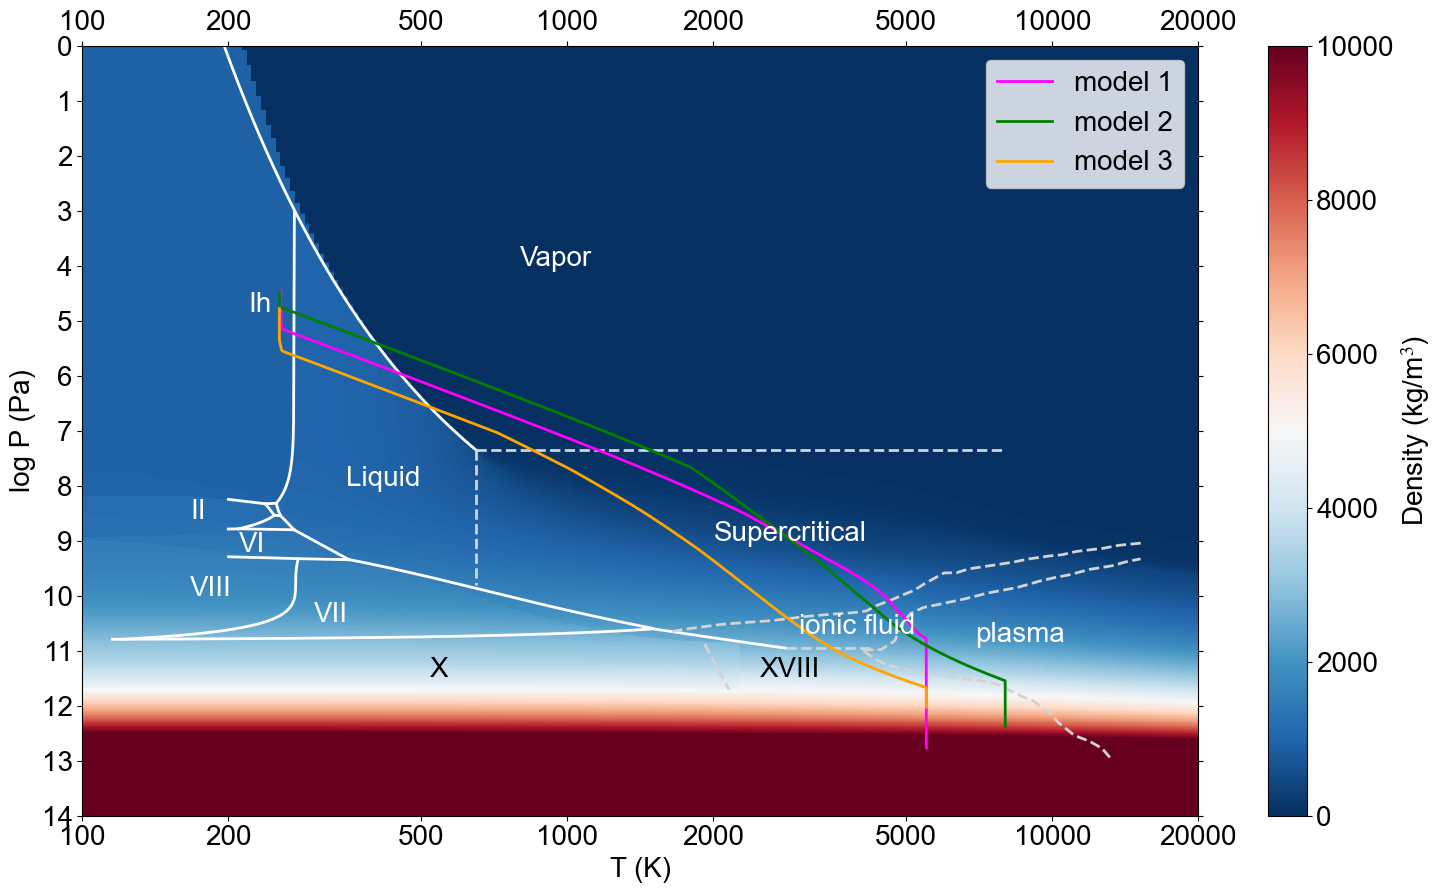

In [18]:
overplot_pt_AQUA([plist3l, plist4l, plist_water_world], 
                 [tlist3l, tlist4l, tlist_water_world], 
                 ['model 1', 'model 2', 'model 3'])

P-T profile of model 2 is in good match with Madhusudhan et al. (2020). I assumed higher central temperture for model 3 so the shape of P-T profile looks different.

# (3) Generate Uranus and Neptune models 

The model input parameters come from Nettelmann et al. (2013). `CORGI` results are compared with the original paper.

Key model input/output parameters from Nettelmann+2013 are listed below before each model run.

The goal is to match their Fig. 4 ($\rho$ vs $r$ and $m$ vs $r$) and Fig. 5 ($\rho$ vs $P$). In addition, we need to match the total M and R given in their tables. They are assuming rocky cores without iron, so here I will use three layer (MgSiO3, H2O, H/He) model as well.

Also useful to know $T_{\rm eq}$ of Uranus and Neptune are 58.1 and 46.6 K.

## Model U1

We start with model U1 with
- Pc = 8.2114e2 GPa
- Tc = 6083.6 K
- Ms = 14.5322753 Me
- Rs = 3.979310 Re
- Ts = 76 K
- Mc (mass of rocky core) = 0.61 Me
- Mz (mass of rock+water) = 12.4 Me

Mc and Mz implies the layer mass fraction of this case should be 0:0.61:11.79:2.1322753, or **0:41976:811298:146726**

The first run following the above parameters got a planet with too low M and R and too high Ts, output copied below:

> The calculated mass and radius are
>
> 11.24096503674964 Me 2.7897833935018053 Re
>
> Surface temperature is 461.8346958048973 K

And mass fraction of the H/He layer is too low:

> Masses at layer boundaries are 0.6100225199746249 Me, 10.63090751388518 Me 3.500288983566879e-05 Me
>
> Which corresponds to layer mass fraction of 0.054268:0.945729:0.000003

Therefore I need to change the parameters, especially Pc and Tc a bit to match the derised M and R. This is the case for all models below.

In [19]:
# track the time performance of the code
begin_time = datetime.datetime.now()

# call the function
pmass_u1, pmass_calc_u1, \
rs_u1, ps_u1, ts_u1, rhos_u1, mlist_u1, \
rlist_u1, plist_u1, tlist_u1, rholist_u1, taulist_u1, \
mboundary_u1, rboundary_u1, pboundary_u1, tboundary_u1, _ = \
    smr.run_single_planet_4layers(
        pmass=14.5322753*smr.Me, 
        layer_mass_fractions=[0, 41976, 811298, 146726], 
        pc=1008.1e9, # pc=1008.1 GPa is an OK guess
        ps=301.0, 
        tc=6083.6, 
        rc=10.0,
        delr=100.0,
        bc_ignore='',
        pradius=3.97931*smr.Re, 
        mmw=3.8504579876320796e-27, 
        teff=50.0, 
        teq=76.0,
        guillot_f=0.5, 
        guillot_gamma=1.0,
        maxsteps=2000000
)

# print results
print()
print("Nettelmann+2013 Uranus model 1 finished.")
print("Execution time: ", datetime.datetime.now() - begin_time)
print()

print("The measured mass and radius of Uranus are")
print("14.53 Me\t3.98 Re")
print("The calculated mass and radius are")
print(pmass_calc_u1/smr.Me, "Me", rlist_u1[-1]/smr.Re, "Re")
print("Surface pressure is", plist_u1[-1]/1.0e5, "bar")
print("Surface temperature is", tlist_u1[-1], "K")
ml0 = mboundary_u1[0]
ml1 = (mboundary_u1[1]-mboundary_u1[0])
ml2 = (mboundary_u1[2]-mboundary_u1[1])
print("Mass of each layer is", ml0/smr.Me, "Me,", ml1/smr.Me, "Me", ml2/smr.Me, "Me")
print("Which corresponds to layer mass fraction of %f:%f:%f" % (ml0/pmass_calc_u1, 
                                                                ml1/pmass_calc_u1, 
                                                                ml2/pmass_calc_u1))

Iteration stopped at step 45673, P = 7559109.657220 bar, M = 0.610038 M_Earth, R = 0.716891 R_Earth
Iteration stopped at step 124635, P = 305540.063018 bar, M = 12.400025 M_Earth, R = 2.673177 R_Earth
Calculating H/He envelope (convective layer) ...
Iteration stopped at step 107349, P = 0.003007 bar, M = 14.515752 M_Earth, R = 4.358140 R_Earth
H/He envelope (convective layer) simulation completed.
Execution time:  0:00:01.808968
The RCB is at P = 1.778519 bar
Calculating H/He envelope (radiative layer) ...


/Users/linzifan/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Iteration stopped at step 2988, P = 0.003008 bar, M = 14.515752 M_Earth, R = 4.358124 R_Earth
H/He envelope (radiative layer) simulation completed.
Execution time:  0:00:00.253526
Optical depth = 1 at 0.419261 bar

Nettelmann+2013 Uranus model 1 finished.
Execution time:  0:00:04.010690

The measured mass and radius of Uranus are
14.53 Me	3.98 Re
The calculated mass and radius are
14.515743525582272 Me 4.3217720922932035 Re
Surface pressure is 0.41926142876322803 bar
Surface temperature is 76.0 K
Mass of each layer is 0.610038241748156 Me, 11.789986890875937 Me 2.115718392958179 Me
Which corresponds to layer mass fraction of 0.042026:0.812221:0.145753


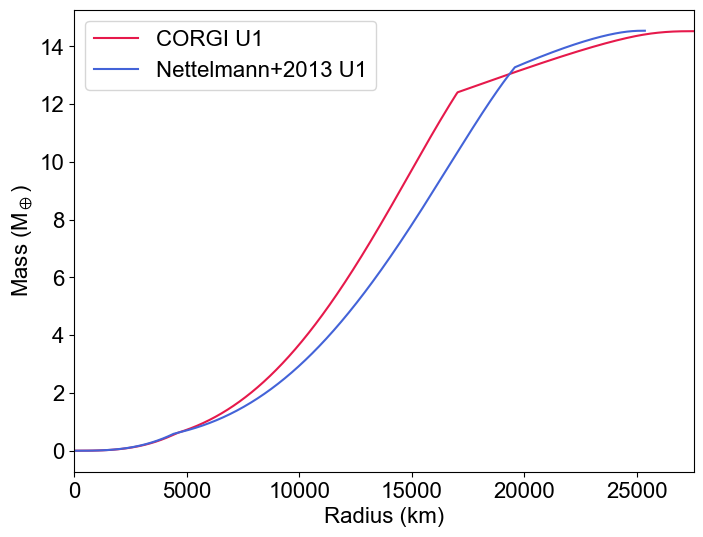

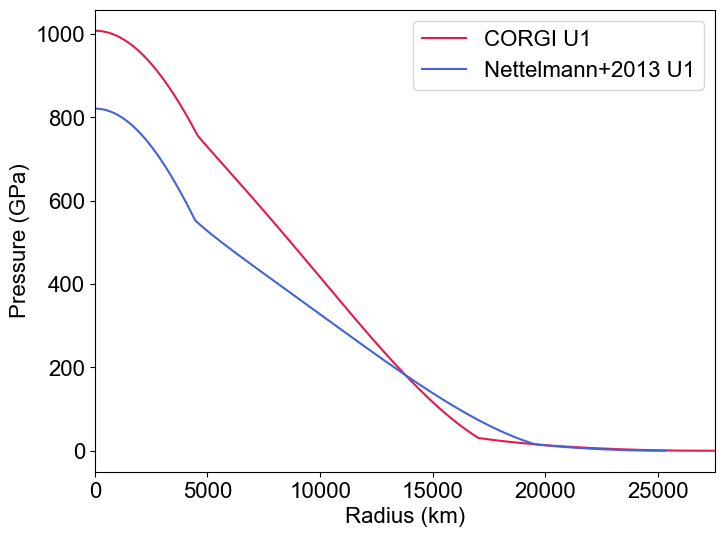

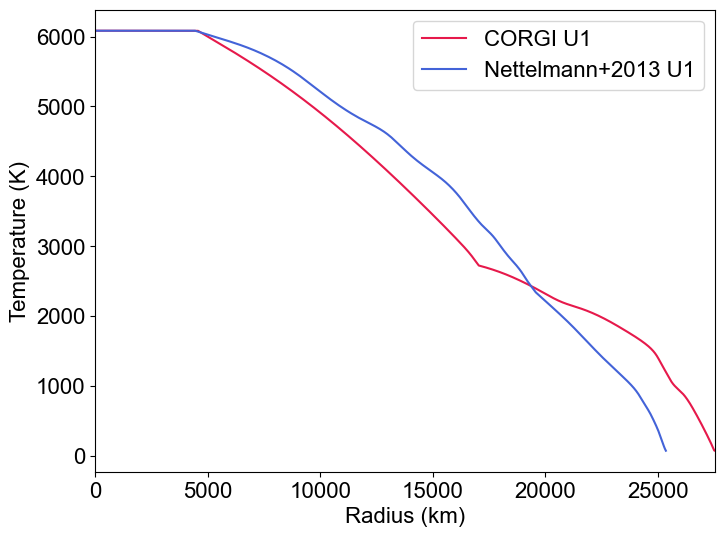

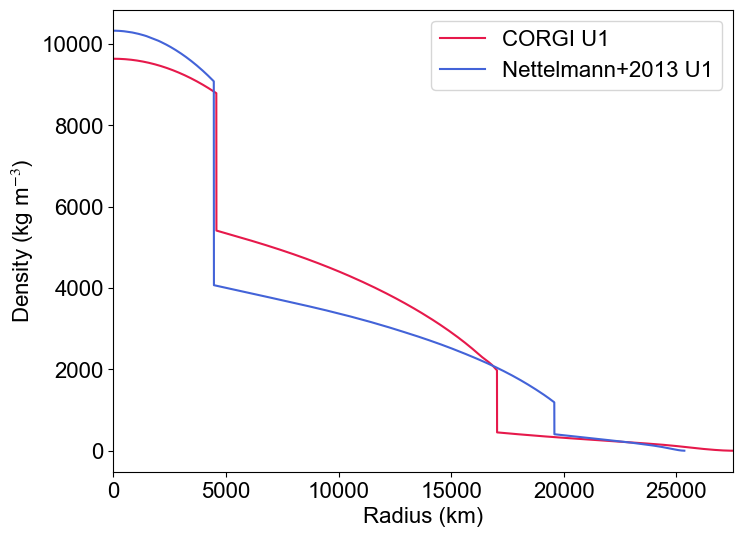

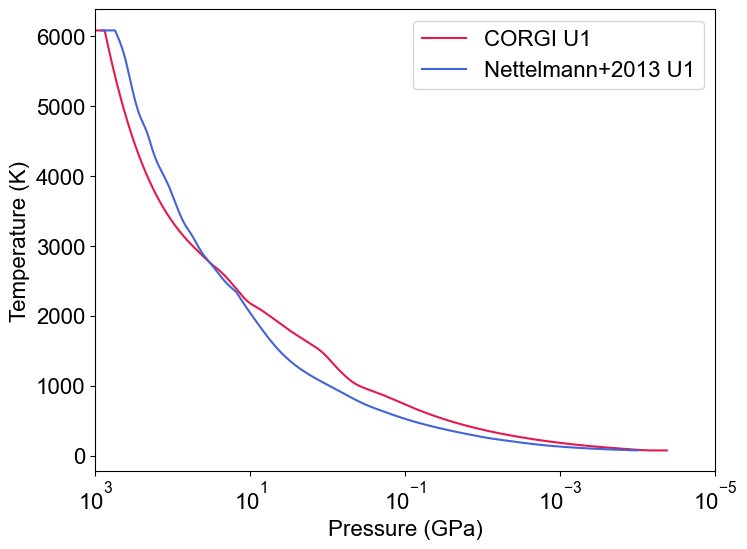

In [20]:
# read Nettelmann+2013 data, convert to the same (SI) unit, and overplot with my model
n13_u1 = np.genfromtxt('Data/Nettelmann2013_table_U1.dat')
n13_u1 = np.transpose(n13_u1)
n13_u1_m = n13_u1[0] * smr.Me # convert Me to kg
n13_u1_r = n13_u1[2] * smr.Re # convert Re to m
n13_u1_p = n13_u1[1] * 1.0e9 # convert GPa to Pa
n13_u1_t = n13_u1[3]
n13_u1_rho = n13_u1[4] * 1.0e3 # convert g/cm3 to kg/m3

pltmr.overplot_multiple_planets([mlist_u1, n13_u1_m], [rlist_u1, n13_u1_r], [plist_u1, n13_u1_p], 
                                [tlist_u1, n13_u1_t], [rholist_u1, n13_u1_rho],
                                ['CORGI U1', 'Nettelmann+2013 U1'])

The most significant deviation is that my Uranus is 0.3 Re puffier than Nettelmann+2013 model. My water layer is cooler and denser, because the AQUA EOS is for pure water, while Nettelmann+2013 considered light elements (H/He) mixing into the icy mantle. My H/He layer (starting from 10 GPa), however, is warmer until abuot 100 bar (1.0e-1 GPa) and likely less dense because of this. H/He has greater influence on the total radius, so the final planet is puffier. In addition, their water and H/He layer seem to follow the same adiabatic profile ($T$ vs $r$ plot), while my model predicts very different adiabatic gradients for the two layers (again, likely an EOS difference).

## Model U2
- Pc = 7.9082e2 GPa
- Tc = 6523.8 K
- rhoc = 1.0198e1 g/cm3
- Ms = 14.5359582 Me
- Rs = 3.977743 Re
- Ts = 76 K
- Mc (mass of rocky core) = 0.36 Me
- Mz (mass of rock+water) = 12.7 Me

Mc and Mz implies the layer mass fraction of this case should be 0.36, 12.34, 1.8359582, or **24766, 848929, 126305**

In [21]:
# track the time performance of the code
begin_time = datetime.datetime.now()

# call the function
pmass_u2, pmass_calc_u2, \
rs_u2, ps_u2, ts_u2, rhos_u2, mlist_u2, \
rlist_u2, plist_u2, tlist_u2, rholist_u2, taulist_u2, \
mboundary_u2, rboundary_u2, pboundary_u2, tboundary_u2, _ = \
    smr.run_single_planet_4layers(
        pmass=14.5359582*smr.Me, 
        layer_mass_fractions=[0, 24766, 848929, 126305], 
        pc=934.5e9, # pc=934.5 GPa is an OK guess
        ps=301.0, 
        tc=6523.8, 
        rc=10.0, 
        delr=100.0,
        bc_ignore='',
        pradius=3.97931*smr.Re, 
        mmw=3.8504579876320796e-27, 
        teff=50.0, 
        teq=76.0,
        guillot_f=0.5, 
        guillot_gamma=1.0,
        maxsteps=2000000
)

# print results
print()
print("Nettelmann+2013 Uranus model 2 finished.")
print("Execution time: ", datetime.datetime.now() - begin_time)
print()

print("The measured mass and radius of Uranus are")
print("14.54 Me\t3.98 Re")
print("The calculated mass and radius are")
print(pmass_calc_u2/smr.Me, "Me", rlist_u2[-1]/smr.Re, "Re")
print("Surface pressure is", plist_u2[-1]/1.0e5, "bar")
print("Surface temperature is", tlist_u2[-1], "K")
ml0 = mboundary_u2[0]
ml1 = (mboundary_u2[1]-mboundary_u2[0])
ml2 = (mboundary_u2[2]-mboundary_u2[1])
print("Mass of each layer is", ml0/smr.Me, "Me,", ml1/smr.Me, "Me", ml2/smr.Me, "Me")
print("Which corresponds to layer mass fraction of %f:%f:%f" % (ml0/pmass_calc_u2, 
                                                                ml1/pmass_calc_u2, 
                                                                ml2/pmass_calc_u2))

Iteration stopped at step 38426, P = 7611035.619734 bar, M = 0.360000 M_Earth, R = 0.603141 R_Earth
Iteration stopped at step 134907, P = 264193.850300 bar, M = 12.700006 M_Earth, R = 2.720658 R_Earth
Calculating H/He envelope (convective layer) ...
Iteration stopped at step 100589, P = 0.003005 bar, M = 14.516506 M_Earth, R = 4.299515 R_Earth
H/He envelope (convective layer) simulation completed.
Execution time:  0:00:01.715927
The RCB is at P = 1.260759 bar
Calculating H/He envelope (radiative layer) ...
Iteration stopped at step 2753, P = 0.003006 bar, M = 14.516506 M_Earth, R = 4.299515 R_Earth
H/He envelope (radiative layer) simulation completed.
Execution time:  0:00:00.232828
Optical depth = 1 at 0.385148 bar

Nettelmann+2013 Uranus model 2 finished.
Execution time:  0:00:03.901270

The measured mass and radius of Uranus are
14.54 Me	3.98 Re
The calculated mass and radius are
14.516498129569174 Me 4.264732381101868 Re
Surface pressure is 0.3851481757756145 bar
Surface temperatur

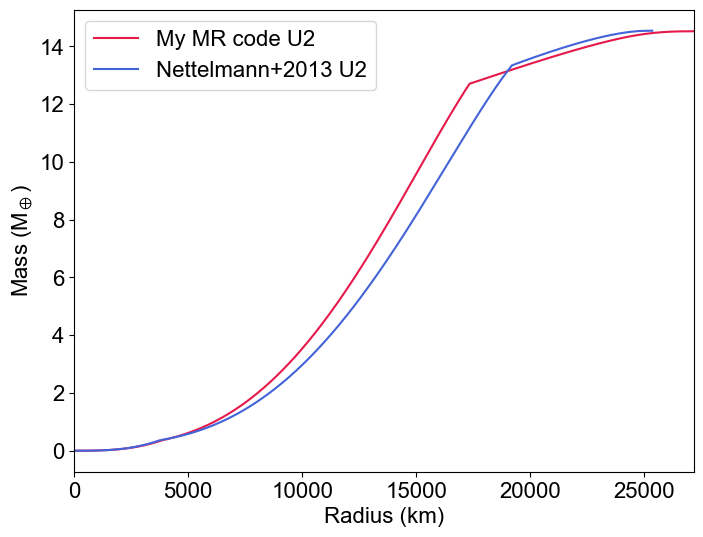

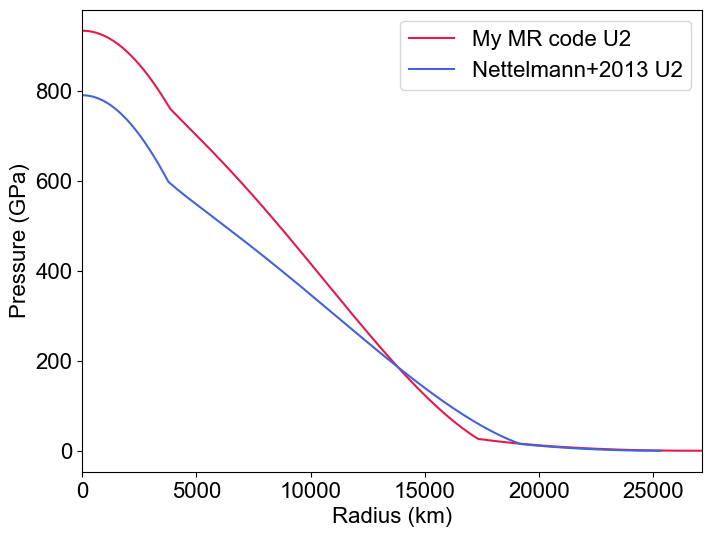

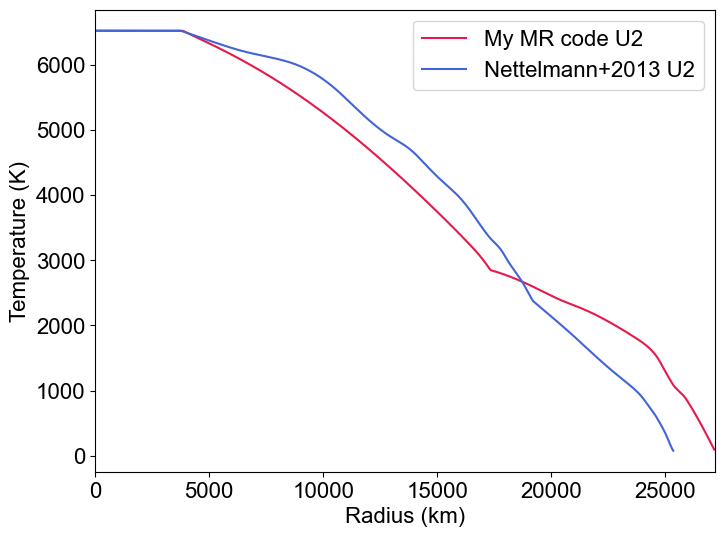

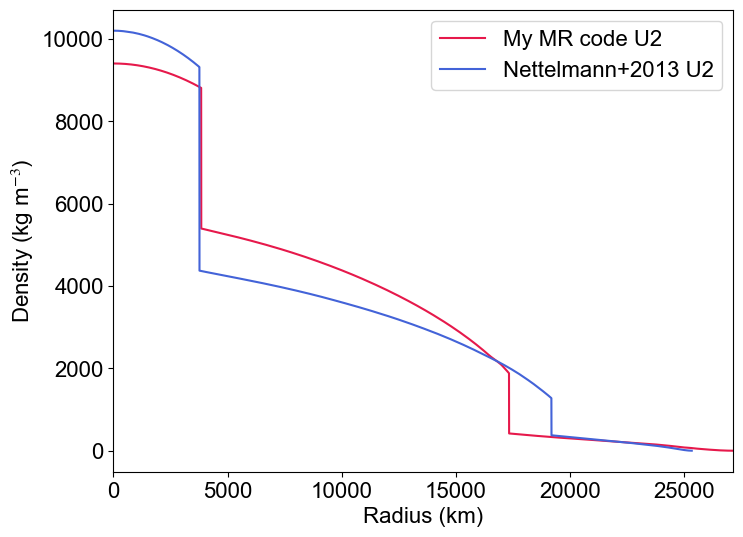

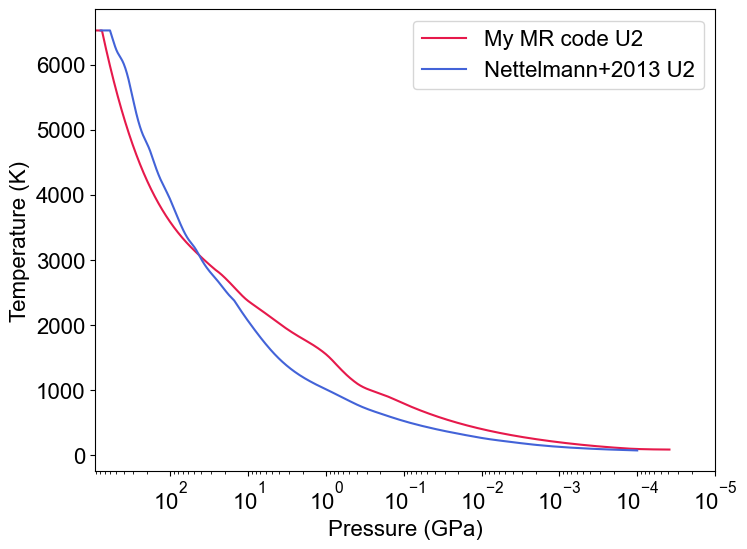

In [22]:
# read Nettelmann+2013 data, convert to the same (SI) unit, and overplot with my model
n13_u2 = np.genfromtxt('Data/Nettelmann2013_table_U2.dat')
n13_u2 = np.transpose(n13_u2)
n13_u2_m = n13_u2[0] * smr.Me # convert Me to kg
n13_u2_r = n13_u2[2] * smr.Re # convert Re to m
n13_u2_p = n13_u2[1] * 1.0e9 # convert GPa to Pa
n13_u2_t = n13_u2[3]
n13_u2_rho = n13_u2[4] * 1.0e3 # convert g/cm3 to kg/m3

pltmr.overplot_multiple_planets([mlist_u2, n13_u2_m], [rlist_u2, n13_u2_r], [plist_u2, n13_u2_p], 
                                [tlist_u2, n13_u2_t], [rholist_u2, n13_u2_rho],
                                ['My MR code U2', 'Nettelmann+2013 U2'])

The planetary radius in this case is again about 0.3 Re greater than the actual radius of Uranus. To match M and R, my code will require less H/He mass fraction and more core or water mass fraction compared to Nettelmann+2013. One thing to notice is that in my T(P) plot, the upper H/He atmosphere (around 3.0e-3 GPa or 30 bar, i.e., the RCB which is located at 36.885158 bar) has a temperature gradient that is decreasing much more rapidly than the Nettelmann+2013 adiabatic profile.

## Model N1
- Pc = 1.6411e3 GPa
- Tc = 5520.3 K
- rhoc = 1.3105e1 g/cm3
- Ms = 17.1480213 Me
- Rs = 3.859248 Re
- Ts = 72 K
- Mc (mass of rocky core) = 3.15 Me
- Mz (mass of rock+water) = 14.4 Me

Mc and Mz implies the layer mass fraction of this case should be 3.15, 11.25, 2.7480213, or **183695, 656052, 160253**

In [23]:
# track the time performance of the code
begin_time = datetime.datetime.now()

# call the function
pmass_n1, pmass_calc_n1, \
rs_n1, ps_n1, ts_n1, rhos_n1, mlist_n1, \
rlist_n1, plist_n1, tlist_n1, rholist_n1, taulist_n1, \
mboundary_n1, rboundary_n1, pboundary_n1, tboundary_n1, _ = \
    smr.run_single_planet_4layers(
        pmass=17.1480213*smr.Me, 
        layer_mass_fractions=[0, 183695, 656052, 160253], 
        pc=1771.6e9, # pc=1771.6 GPa is an OK guess
        ps=301.0, 
        tc=5520.3, 
        rc=10.0, 
        delr=100.0,
        bc_ignore='',
        pradius=3.97931*smr.Re, 
        mmw=3.8504579876320796e-27, 
        teff=50.0, 
        teq=75.1, # using 75.1 instead of 72 to avoid opacity out of bound
        guillot_f=0.5, 
        guillot_gamma=1.0,
        maxsteps=2000000
)

# print results
print()
print("Nettelmann+2013 Neptune model 1 finished.")
print("Execution time: ", datetime.datetime.now() - begin_time)
print()

print("The measured mass and radius of Uranus are")
print("17.15 Me\t3.86 Re")
print("The calculated mass and radius are")
print(pmass_calc_n1/smr.Me, "Me", rlist_n1[-1]/smr.Re, "Re")
print("Surface pressure is", plist_n1[-1]/1.0e5, "bar")
print("Surface temperature is", tlist_n1[-1], "K")
ml0 = mboundary_n1[0]
ml1 = (mboundary_n1[1]-mboundary_n1[0])
ml2 = (mboundary_n1[2]-mboundary_n1[1])
print("Mass of each layer is", ml0/smr.Me, "Me,", ml1/smr.Me, "Me", ml2/smr.Me, "Me")
print("Which corresponds to layer mass fraction of %f:%f:%f" % (ml0/pmass_calc_n1, 
                                                                ml1/pmass_calc_n1, 
                                                                ml2/pmass_calc_n1))

Iteration stopped at step 76232, P = 8481746.895046 bar, M = 3.150062 M_Earth, R = 1.196548 R_Earth
Iteration stopped at step 91117, P = 467365.820857 bar, M = 14.400073 M_Earth, R = 2.626732 R_Earth
Calculating H/He envelope (convective layer) ...
Iteration stopped at step 110175, P = 0.003005 bar, M = 17.124794 M_Earth, R = 4.356052 R_Earth
H/He envelope (convective layer) simulation completed.
Execution time:  0:00:01.846168
The RCB is at P = 2.815656 bar
Calculating H/He envelope (radiative layer) ...
Iteration stopped at step 2713, P = 0.003003 bar, M = 17.124794 M_Earth, R = 4.356052 R_Earth
H/He envelope (radiative layer) simulation completed.
Execution time:  0:00:00.212041
Optical depth = 1 at 0.457774 bar

Nettelmann+2013 Neptune model 1 finished.
Execution time:  0:00:04.221530

The measured mass and radius of Uranus are
17.15 Me	3.86 Re
The calculated mass and radius are
17.12478558366698 Me 4.324691571181918 Re
Surface pressure is 0.45777387605573944 bar
Surface temperatur

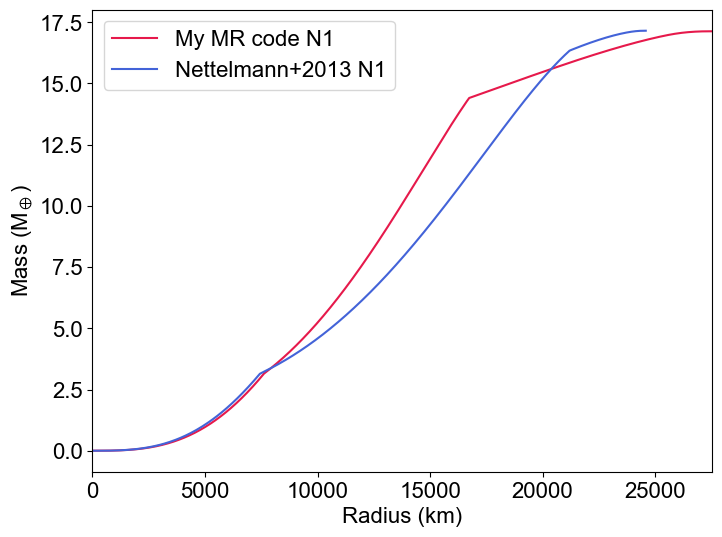

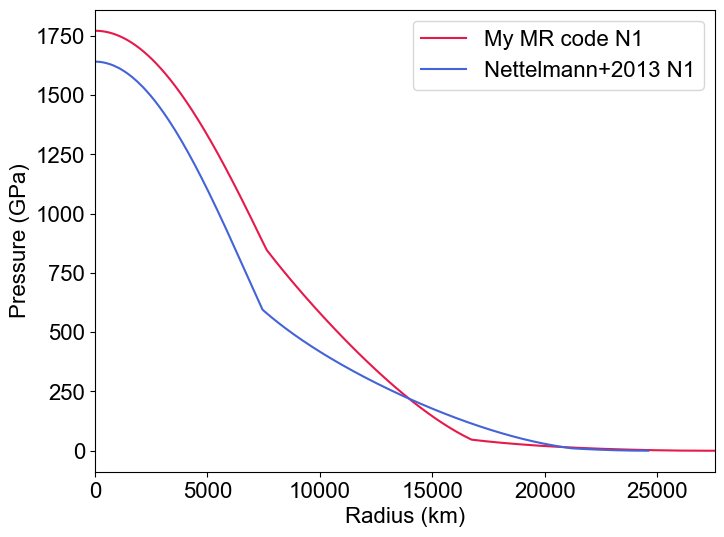

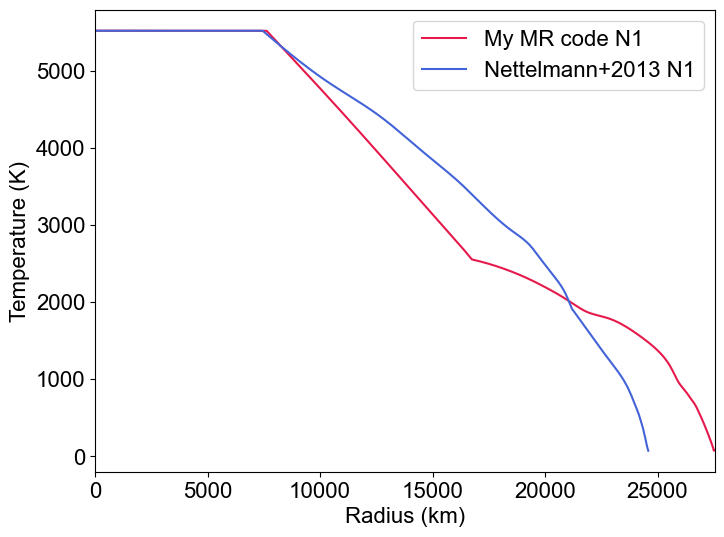

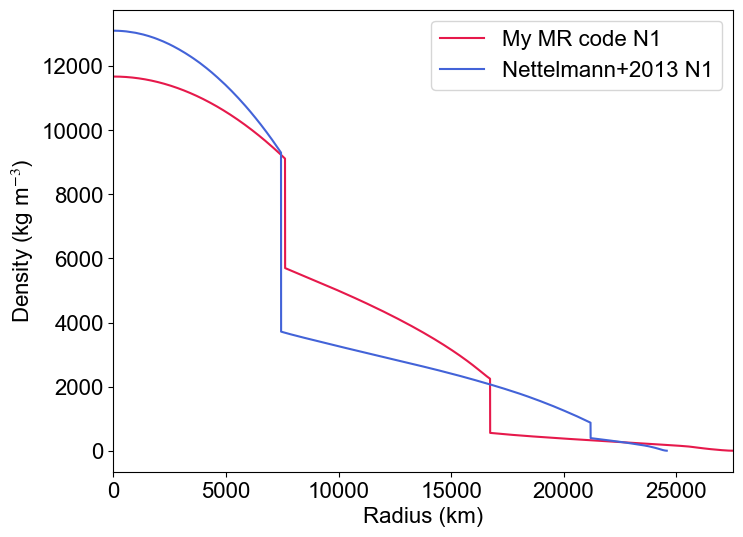

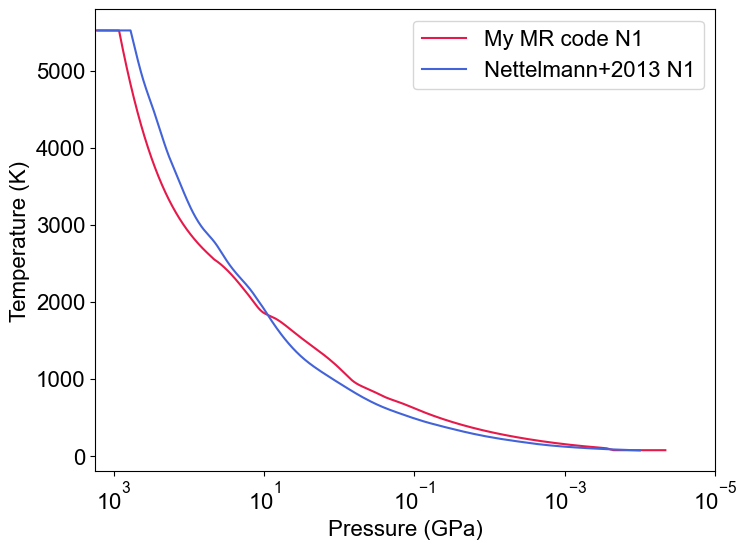

In [24]:
# read Nettelmann+2013 data, convert to the same (SI) unit, and overplot with my model
n13_n1 = np.genfromtxt('Data/Nettelmann2013_table_N1.dat')
n13_n1 = np.transpose(n13_n1)
n13_n1_m = n13_n1[0] * smr.Me # convert Me to kg
n13_n1_r = n13_n1[2] * smr.Re # convert Re to m
n13_n1_p = n13_n1[1] * 1.0e9 # convert GPa to Pa
n13_n1_t = n13_n1[3]
n13_n1_rho = n13_n1[4] * 1.0e3 # convert g/cm3 to kg/m3

pltmr.overplot_multiple_planets([mlist_n1, n13_n1_m], [rlist_n1, n13_n1_r], [plist_n1, n13_n1_p], 
                                [tlist_n1, n13_n1_t], [rholist_n1, n13_n1_rho],
                                ['My MR code N1', 'Nettelmann+2013 N1'])

## Model N2b
- Pc = 1.0517e3 GPa
- Tc = 5073.1 K
- rhoc = 1.1220e1 g/cm3
- Ms = 17.1480213 Me
- Rs = 3.863636 Re
- Ts = 72 K
- Mc (mass of rocky core) = 0.35 Me
- Mz (mass of rock+water) = 14.4 Me

Mc and Mz implies the layer mass fraction of this case should be 0.35, 14.05, 2.7480213, or **20411, 819336, 160253**

In [25]:
# track the time performance of the code
begin_time = datetime.datetime.now()

# call the function
pmass_n2b, pmass_calc_n2b, \
rs_n2b, ps_n2b, ts_n2b, rhos_n2b, mlist_n2b, \
rlist_n2b, plist_n2b, tlist_n2b, rholist_n2b, taulist_n2b, \
mboundary_n2b, rboundary_n2b, pboundary_n2b, tboundary_n2b, _ = \
    smr.run_single_planet_4layers(pmass=17.1480213*smr.Me, layer_mass_fractions=[0, 20411, 819336, 160253], 
                                  pc=1152.75e9, ps=301.0, tc=5073.1, # pc=? GPa is an OK guess
                                  rc=10.0, delr=100.0,
                                  bc_ignore='',
                                  pradius=3.97931*smr.Re, mmw=3.8504579876320796e-27, 
                                  teff=50.0, teq=75.1, # using 75.1 instead of 72 to avoid opacity out of bound
                                  guillot_f=0.5, guillot_gamma=1.0,
                                  maxsteps=2000000)

# print results
print()
print("Nettelmann+2013 Neptune model 1 finished.")
print("Execution time: ", datetime.datetime.now() - begin_time)
print()

print("The measured mass and radius of Uranus are")
print("17.15 Me\t3.86 Re")
print("The calculated mass and radius are")
print(pmass_calc_n2b/smr.Me, "Me", rlist_n2b[-1]/smr.Re, "Re")
print("Surface pressure is", plist_n2b[-1]/1.0e5, "bar")
print("Surface temperature is", tlist_n2b[-1], "K")
ml0 = mboundary_n2b[0]
ml1 = (mboundary_n2b[1]-mboundary_n2b[0])
ml2 = (mboundary_n2b[2]-mboundary_n2b[1])
print("Mass of each layer is", ml0/smr.Me, "Me,", ml1/smr.Me, "Me", ml2/smr.Me, "Me")
print("Which corresponds to layer mass fraction of %f:%f:%f" % (ml0/pmass_calc_n2b, 
                                                                ml1/pmass_calc_n2b, 
                                                                ml2/pmass_calc_n2b))

Iteration stopped at step 37153, P = 9657169.923896 bar, M = 0.350018 M_Earth, R = 0.583160 R_Earth
Iteration stopped at step 136598, P = 422222.128082 bar, M = 14.400053 M_Earth, R = 2.727219 R_Earth
Calculating H/He envelope (convective layer) ...
Iteration stopped at step 104338, P = 0.003009 bar, M = 17.130658 M_Earth, R = 4.364921 R_Earth
H/He envelope (convective layer) simulation completed.
Execution time:  0:00:01.765597
The RCB is at P = 5.728698 bar
Calculating H/He envelope (radiative layer) ...
Iteration stopped at step 2995, P = 0.003003 bar, M = 17.130658 M_Earth, R = 4.364874 R_Earth
H/He envelope (radiative layer) simulation completed.
Execution time:  0:00:00.233231
Optical depth = 1 at 0.457218 bar

Nettelmann+2013 Neptune model 1 finished.
Execution time:  0:00:03.926049

The measured mass and radius of Uranus are
17.15 Me	3.86 Re
The calculated mass and radius are
17.13064933492681 Me 4.333402919478889 Re
Surface pressure is 0.45721780215653984 bar
Surface temperatu

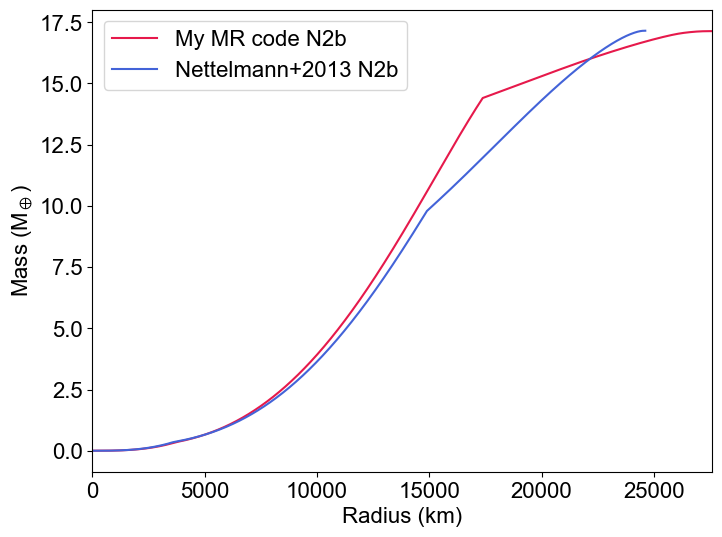

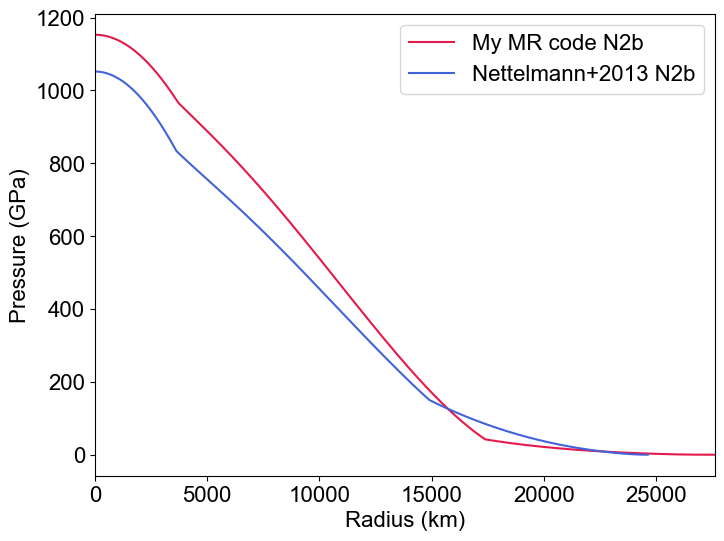

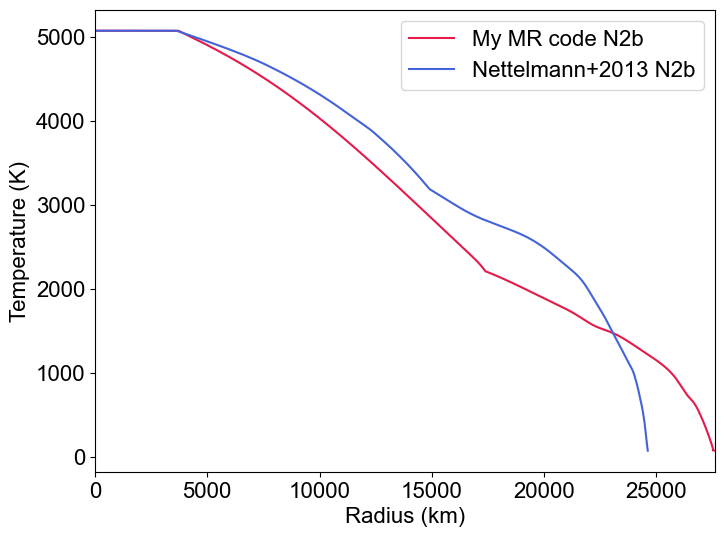

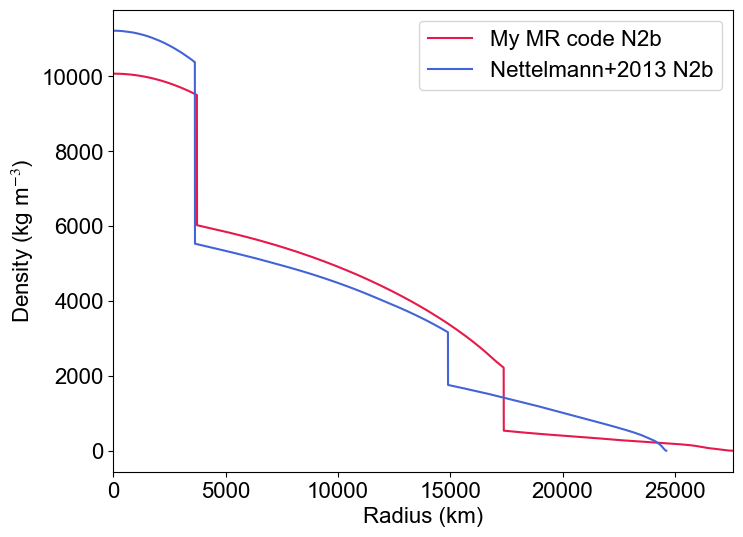

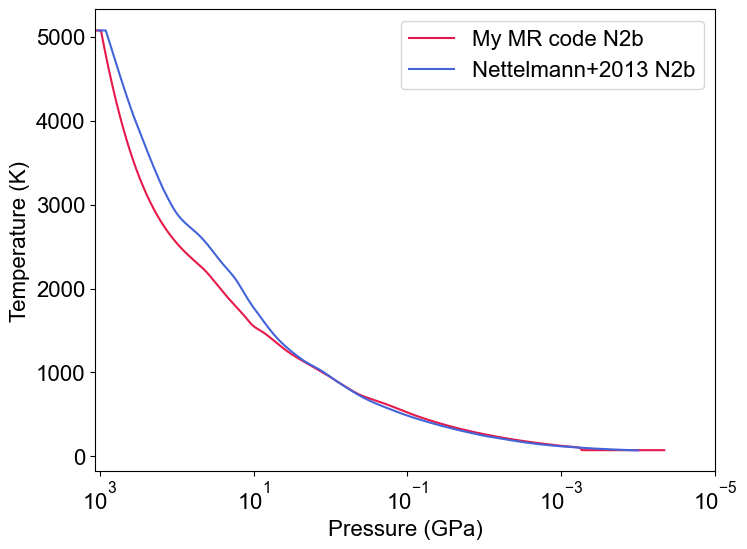

In [26]:
# read Nettelmann+2013 data, convert to the same (SI) unit, and overplot with my model
n13_n2b = np.genfromtxt('Data/Nettelmann2013_table_N2b.dat')
n13_n2b = np.transpose(n13_n2b)
n13_n2b_m = n13_n2b[0] * smr.Me # convert Me to kg
n13_n2b_r = n13_n2b[2] * smr.Re # convert Re to m
n13_n2b_p = n13_n2b[1] * 1.0e9 # convert GPa to Pa
n13_n2b_t = n13_n2b[3]
n13_n2b_rho = n13_n2b[4] * 1.0e3 # convert g/cm3 to kg/m3

pltmr.overplot_multiple_planets([mlist_n2b, n13_n2b_m], [rlist_n2b, n13_n2b_r], [plist_n2b, n13_n2b_p], 
                                [tlist_n2b, n13_n2b_t], [rholist_n2b, n13_n2b_rho],
                                ['My MR code N2b', 'Nettelmann+2013 N2b'])

As another test, let's try overplotting all P-T profiles onto the water phase diagram

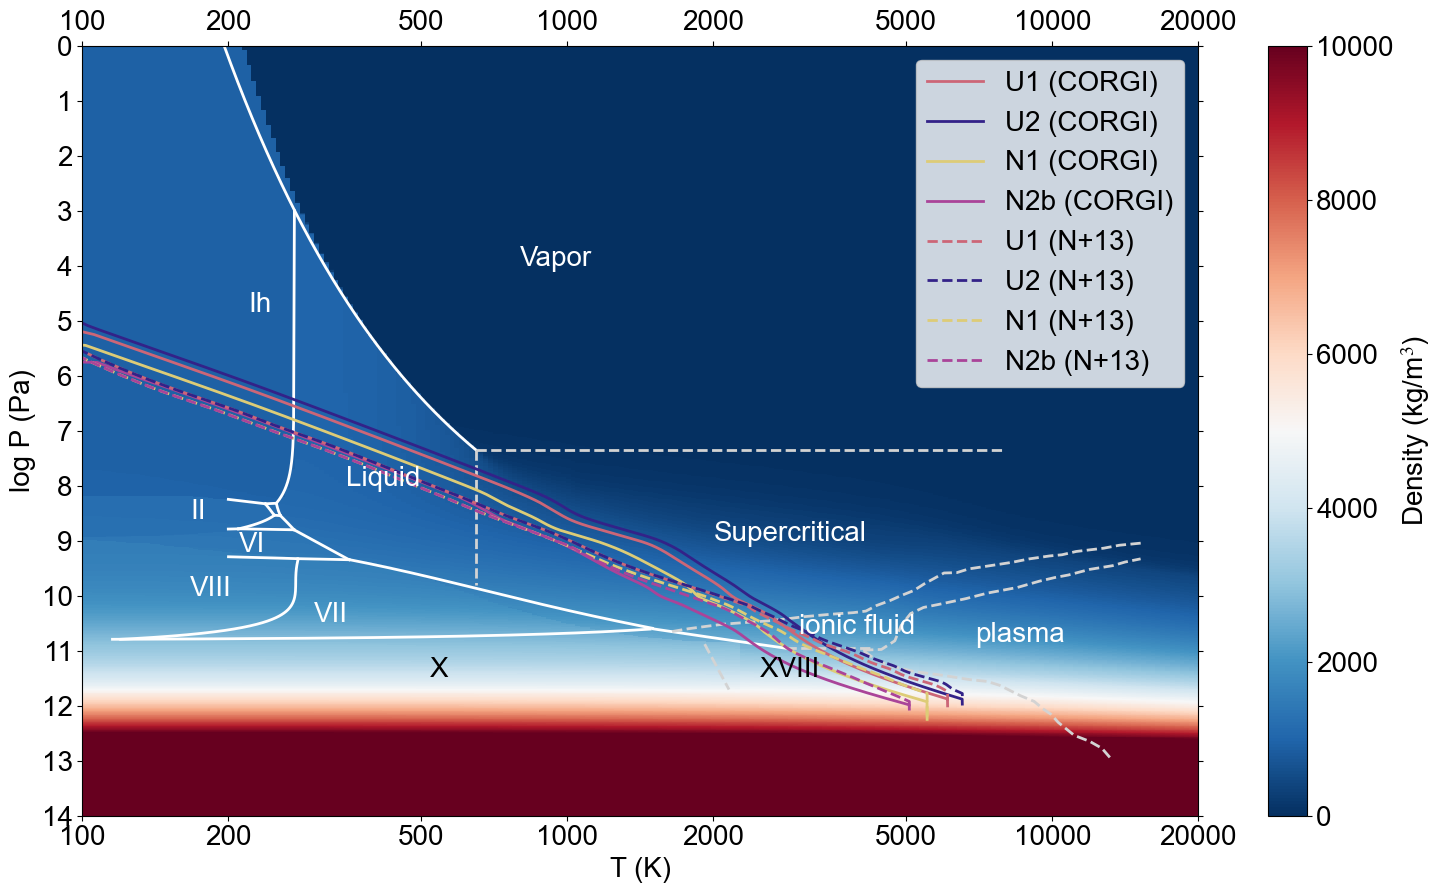

30.554006301761362 26.419385030017526 46.73658208567966 42.2222128081788


In [27]:
overplot_pt_AQUA([plist_u1, plist_u2, plist_n1, plist_n2b, n13_u1_p, n13_u2_p, n13_n1_p, n13_n2b_p], 
                 [tlist_u1, tlist_u2, tlist_n1, tlist_n2b, n13_u1_t, n13_u2_t, n13_n1_t, n13_n2b_t], 
                 ['U1 (CORGI)', 'U2 (CORGI)', 'N1 (CORGI)', 'N2b (CORGI)', 
                  'U1 (N+13)', 'U2 (N+13)', 'N1 (N+13)', 'N2b (N+13)'],
                 colors=['#CC6677', '#332288', '#DDCC77', '#AA4499']*2,
                 linestyles=['-']*4 + ['--']*4)

# print pressure at the H/He-H2O boundary
print(pboundary_u1[1]/1.0e9, pboundary_u2[1]/1.0e9, pboundary_n1[1]/1.0e9, pboundary_n2b[1]/1.0e9)

Combining the plot above and pressures at the H/He-H2O boundary, it seems that my model predicts the atmosphere is in contact with supercritical water layer at its bottom. Besides, all models predict the P-T profiles of Uranus and Neptune will go through the ionic fluid and supercritical ice phases, which is a good sign for magnetic field generation.

At this point, I have demonstrated how to use the forward modeling component of `CORGI` to simulate different types of planets. Refer to the other tutorials for other functionalities, e.g., how to generate M-R curves and ternary diagrams for planets.